# Task: potential field for path planning

Given a target point and three obstacles (defined in the provided code), answer the following two questions:

1. Implement two functions (`attractive_potential`, `repulsive_potential`), and then use the potential field method to plan a collision-free path from the starting point to the target point while avoiding all obstacles. You can use pytorch to calculate the requried gradient.

2. Visualize the planned 2-D path, clearly showing the start point, target point, obstacles, and the path generated by your planner.

In [1]:
# import necessary python packages
import torch
import matplotlib.pyplot as plt

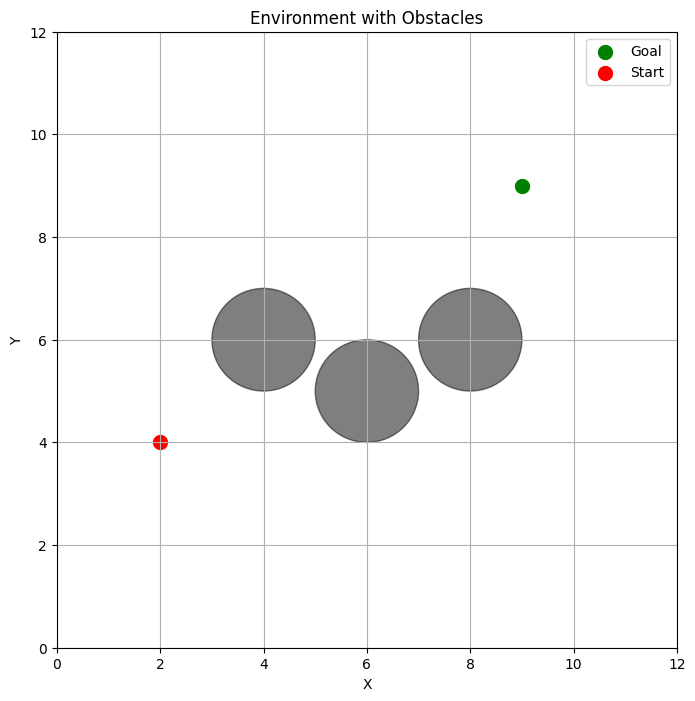

In [2]:
# Parameters for the robot and the environment
Obstacle_radius = 1  # radius of the circular obstacles
Goal = torch.tensor([9.0, 9.0], dtype=torch.float32, requires_grad=False)  # goal position
Start = torch.tensor([2.0, 4.0], dtype=torch.float32)  # start position
Obstacles = torch.tensor([[4.0, 6.0], [6.0, 5.0], [8.0, 6.0]], dtype=torch.float32)  # obstacle positions
Threshold = 2 # Threshold (i.e., rho_0), influence distance from obstacle surface

# The code below provides an example of how to visualize the environment, you can reuse it in your answers.
grid_size = 12  # size of the grid
# Plotting the environment and path
plt.figure(figsize=(8, 8))
plt.scatter(Goal[0], Goal[1], color="green", label="Goal", s=100)
plt.scatter(Start[0], Start[1], color="red", label="Start", s=100)
for obs in Obstacles.numpy():
    circle = plt.Circle((obs[0], obs[1]), Obstacle_radius, color="black", alpha=0.5)
    plt.gca().add_artist(circle)
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Environment with Obstacles")
plt.legend()
plt.grid(True)
plt.show()


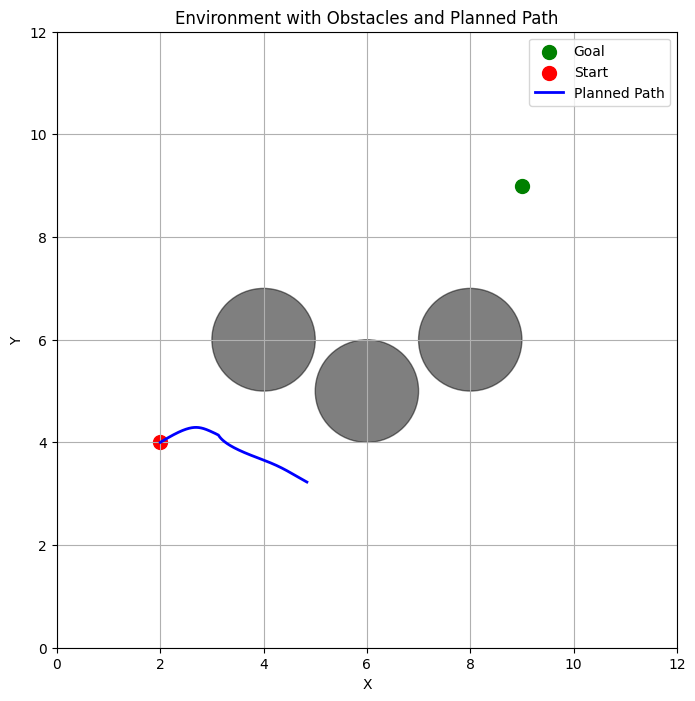

In [ ]:
# parameters for attractive force and repulsive force
k_att = 1  # value for the attractive force constant
k_rep = 0.01  # value for the repulsive force constant

# Attractive potential field (towards goal)
def attractive_potential(x, goal):
    """
    Compute the attractive potential that pulls the robot towards the goal.
    
    Args:
        x: Current position of the robot (torch tensor of shape [2])
        goal: Target goal position (torch tensor of shape [2])
    
    Returns:
        Attractive potential value (torch scalar)
    """
    # potential field method for calculating attractive potential
    return k_att * torch.norm(x - goal)

# Repulsive potential field (away from obstacles)
def repulsive_potential(x, obstacles, threshold):
    """
    Compute the repulsive potential that pushes the robot away from obstacles.
    
    IMPORTANT: The repulsive potential should only be active when the robot is within 
    the threshold distance from the OBSTACLE SURFACE, NOT THE OBSTACLE CENTER.
    
    To compute distance to the obstacle surface:
        distance_to_surface = distance_to_center - obstacle_radius
    
    Args:
        x: Current position of the robot (torch tensor of shape [2])
        obstacles: Positions of the obstacles (torch tensor of shape [num_obstacles, 2])
        threshold: Influence distance from obstacle surface (scalar)
    
    Returns:
        Repulsive potential value (torch scalar)
    """
    repulsive_potential_value = 0.0
    for obstacle in obstacles:
        distance_to_center = torch.norm(x - obstacle)
        distance_to_surface = distance_to_center - Obstacle_radius
        if distance_to_surface < threshold:
            repulsive_potential_value += k_rep * (1.0 / distance_to_surface - 1.0 / threshold)
    return repulsive_potential_value

# init robot start pos  
x = Start.clone().detach().requires_grad_(True)

# iteratively compute the robot moving towards the goal using gradient descent
learning_rate = 0.1  # learning rate for gradient descent
max_iterations = 10000  # maximum number of iterations for path planning
path = [x.detach().clone()]  # list to store the planned path
for _ in range(max_iterations):
    # Compute the total potential field (attractive + repulsive)
    total_potential = attractive_potential(x, Goal) + repulsive_potential(x, Obstacles, Threshold)

    # Compute the gradient of the total potential field with respect to the robot's position
    # Here, we use PyTorch's autograd to compute the gradient, which will give us the direction of steepest ascent (i.e., the direction in which the potential increases the most).
    total_potential.backward()

    # Update the robot's position using gradient descent
    with torch.no_grad():
        x -= learning_rate * x.grad

    # Clear the gradient
    x.grad.zero_()

    # Store the current position in the path
    path.append(x.detach().clone())

# Visualise the path on the environment plot
path = torch.stack(path)
plt.figure(figsize=(8, 8))
plt.scatter(Goal[0], Goal[1], color="green", label="Goal", s=100)
plt.scatter(Start[0], Start[1], color="red", label="Start", s=100)
for obs in Obstacles.numpy():
    circle = plt.Circle((obs[0], obs[1]), Obstacle_radius, color="black", alpha=0.5)
    plt.gca().add_artist(circle)
plt.plot(path[:, 0], path[:, 1], color="blue", label="Planned Path", linewidth=2)
plt.xlim(0, grid_size)
plt.ylim(0, grid_size)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Environment with Obstacles and Planned Path")
plt.legend()
plt.grid(True)
plt.show()

# TODO: Use potential fields to perform path planning
# 1. Initialize the robot at the starting position
# 2. Iteratively compute the total potential (attractive + repulsive)
# 3. Use gradient descent to move the robot towards the goal
# 4. Stop when the robot reaches the goal or maximum iterations are reached
# 5. Save the planned path as a list of positions
# 6. After computing the planned path, visualize it on the environment plot (similar to how the environment is visualized above)

# TODO: Write your code here










# Report

Analyze the effects of the coefficients `k_att` and `k_rep` in path planning

Note: You are not asked to write code for this section. Instead, provide your analysis in your report.